# TIGER Challenge — Segmentation Track: Data Preparation
## 256x256 Patch Extraction + Macenko Stain Normalization + 7->3 Class Remap

**Track:** Tissue segmentation (Rest / Tumor / Stroma)
**Input:** Streamed ROI images + tissue masks from `s3://tiger-training/roi-level-annotations/`
**Output:** A UNet-ready patch dataset (images/masks, train/val/test) saved to Google Drive

### Pipeline (per the official TIGER segmentation baseline — these are NOT open questions,
### unlike the detection stain-norm decision; the paper specifies all of these directly)
1. Stream + re-discover image/mask pairs (same classification heuristic as the Segmentation EDA)
2. Basic corrupted-file checks only (matches our earlier scope decision)
3. **Macenko stain normalization** — explicitly required by the baseline for this track
4. **7-class -> 3-class remapping**: `{0:0, 1:1, 2:2, 3:0, 4:0, 5:0, 6:2, 7:0}` (Rest/Tumor/Stroma)
5. **256x256 patch extraction**, tiling each ROI on a non-overlapping grid (with edge padding
   for remainders)
6. Train / val / test split **at the image (slide) level, before patching** — this matters:
   splitting after patching would leak neighboring patches from the same ROI across splits
7. Save patches to Google Drive (images as RGB PNG post-stain-norm, masks as single-channel
   PNG with values 0/1/2)
8. ImageNet mean/std normalization is documented here as a **reference transform** applied at
   training time (in the DataLoader), not baked into the saved patch files — this keeps the
   saved patches visually inspectable and reusable regardless of which backbone you end up using

> **Note:** Run in Google Colab. We stream each raw image/mask pair once, process it, and
> write out only the small final patch dataset — we never bulk-download the raw dataset.


## Step 0 — Setup: install & import libraries

In [12]:
!pip install -q s3fs fsspec scikit-learn opencv-python-headless

In [13]:
import os
import re
import random
from io import BytesIO
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import s3fs

random.seed(42)
np.random.seed(42)


## Step 1 — Mount Google Drive (for the final processed patch dataset)

Only the small, processed patch dataset is saved here — not the raw multi-GB source data.


In [14]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_ROOT = '/content/drive/MyDrive/tiger_dataset/segmentation_patches'
os.makedirs(OUTPUT_ROOT, exist_ok=True)
print(f"Processed patch dataset will be saved to: {OUTPUT_ROOT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processed patch dataset will be saved to: /content/drive/MyDrive/tiger_dataset/segmentation_patches


## Step 2 — Connect to S3 and re-discover image/mask pairs

Same classification heuristic as the Segmentation EDA notebook: both images and masks are
PNGs, so we classify each by pixel-value characteristics (masks only contain small integer
labels 0-7) rather than trusting folder names.


In [15]:
BUCKET_ROOT = "tiger-training/wsirois/roi-level-annotations"
s3 = s3fs.S3FileSystem(anon=True)

print("Discovering all PNG files...")
all_png = s3.glob(f"{BUCKET_ROOT}/**/*.png")
print(f"Found {len(all_png)} total PNG files")


Discovering all PNG files...
Found 4061 total PNG files


In [16]:
def classify_png(s3_path):
    try:
        with s3.open(s3_path, 'rb') as f:
            img_bytes = f.read()
        im = Image.open(BytesIO(img_bytes))
        if im.mode in ('L', 'P', '1', 'I'):
            arr = np.asarray(im.convert('L'))
        else:
            arr = np.asarray(im.convert('L'))
        unique_vals = np.unique(arr)
        if len(unique_vals) <= 10 and unique_vals.max() <= 10:
            return 'mask'
        return 'image'
    except Exception:
        return 'error'

sample_size = min(60, len(all_png))
sample_paths = random.sample(all_png, sample_size)
classifications = {p: classify_png(p) for p in tqdm(sample_paths, desc="Classifying sample")}

mask_dirs, image_dirs = set(), set()
for path, label in classifications.items():
    d = os.path.dirname(path)
    if label == 'mask':
        mask_dirs.add(d)
    elif label == 'image':
        image_dirs.add(d)

all_masks, all_images, ambiguous = [], [], []
for p in all_png:
    d = os.path.dirname(p)
    if d in mask_dirs and d not in image_dirs:
        all_masks.append(p)
    elif d in image_dirs and d not in mask_dirs:
        all_images.append(p)
    else:
        ambiguous.append(p)

for p in tqdm(ambiguous, desc="Resolving ambiguous files"):
    label = classify_png(p)
    if label == 'mask':
        all_masks.append(p)
    elif label == 'image':
        all_images.append(p)

print(f"\n✓ {len(all_masks)} masks, {len(all_images)} images identified")


Classifying sample:   0%|          | 0/60 [00:00<?, ?it/s]

Resolving ambiguous files:   0%|          | 0/151 [00:00<?, ?it/s]


✓ 2030 masks, 2031 images identified


In [17]:
def strip_suffix(fname):
    base = os.path.basename(fname)
    base = re.sub(r'\.(png|PNG)$', '', base)
    base = re.sub(r'(_mask|_tissue|_label)$', '', base, flags=re.IGNORECASE)
    return base

image_stems = {strip_suffix(p): p for p in all_images}
mask_stems = {strip_suffix(p): p for p in all_masks}
matched = sorted(set(image_stems) & set(mask_stems))

print(f"Matched image-mask pairs: {len(matched)}")


Matched image-mask pairs: 2030


## Step 3 — Basic corrupted-file checks

Only basic checks, per our earlier scope decision — no aggressive outlier removal.


In [18]:
corrupted = []
for stem in tqdm(matched, desc="Verifying readability"):
    for p in (image_stems[stem], mask_stems[stem]):
        try:
            with s3.open(p, 'rb') as f:
                img_bytes = f.read()
            Image.open(BytesIO(img_bytes)).verify()
        except Exception as e:
            corrupted.append((p, str(e)[:60]))

print(f"Corrupted/unreadable files: {len(corrupted)}")
for c in corrupted[:10]:
    print(f"  {c}")

# Drop any matched pairs where either file is corrupted
corrupted_paths = set(c[0] for c in corrupted)
matched = [s for s in matched
           if image_stems[s] not in corrupted_paths and mask_stems[s] not in corrupted_paths]
print(f"Usable pairs after corrupted-file check: {len(matched)}")


Verifying readability:   0%|          | 0/2030 [00:00<?, ?it/s]

Corrupted/unreadable files: 0
Usable pairs after corrupted-file check: 2030


## Step 4 — Macenko stain normalization

Same implementation as the Detection data-prep notebook, reused here since this track's
baseline explicitly requires stain normalization (unlike detection, where it was our own
EDA-informed addition).


In [19]:
HE_REFERENCE = np.array([[0.5626, 0.2159],
                          [0.7201, 0.8012],
                          [0.4062, 0.5581]])
MAX_C_REFERENCE = np.array([1.9705, 1.0308])


def macenko_normalize(img_rgb, Io=240, alpha=1, beta=0.15):
    """Macenko et al. (2009) stain normalization. Falls back to original image
    if there isn't enough tissue signal to estimate stain vectors reliably."""
    h, w, c = img_rgb.shape
    img_flat = img_rgb.reshape(-1, 3).astype(np.float64)
    OD = -np.log((img_flat + 1) / Io)
    OD_thresh = OD[np.all(OD > beta, axis=1)]
    if OD_thresh.shape[0] < 10:
        return img_rgb
    try:
        eigvals, eigvecs = np.linalg.eigh(np.cov(OD_thresh.T))
    except np.linalg.LinAlgError:
        return img_rgb
    top_eigvecs = eigvecs[:, [1, 2]]
    proj = OD_thresh.dot(top_eigvecs)
    phi = np.arctan2(proj[:, 1], proj[:, 0])
    min_phi = np.percentile(phi, alpha)
    max_phi = np.percentile(phi, 100 - alpha)
    v1 = top_eigvecs.dot(np.array([np.cos(min_phi), np.sin(min_phi)]))
    v2 = top_eigvecs.dot(np.array([np.cos(max_phi), np.sin(max_phi)]))
    stain_matrix = np.array([v1, v2]).T if v1[0] > v2[0] else np.array([v2, v1]).T
    try:
        C = np.linalg.lstsq(stain_matrix, OD.T, rcond=None)[0]
    except np.linalg.LinAlgError:
        return img_rgb
    max_C = np.percentile(C, 99, axis=1)
    max_C[max_C == 0] = 1e-6
    C_scaled = C * (MAX_C_REFERENCE / max_C)[:, None]
    OD_normalized = HE_REFERENCE.dot(C_scaled)
    img_normalized = Io * np.exp(-OD_normalized)
    img_normalized = np.clip(img_normalized, 0, 255).T.reshape(h, w, 3).astype(np.uint8)
    return img_normalized


## Step 5 — 7-class -> 3-class remap (same as Segmentation EDA)

In [20]:
REMAP = {0: 0, 1: 1, 2: 2, 3: 0, 4: 0, 5: 0, 6: 2, 7: 0}
CLASS_NAMES = {0: 'Rest', 1: 'Tumor', 2: 'Stroma'}

def remap_mask(mask_arr):
    remapped = np.zeros_like(mask_arr)
    for orig, new in REMAP.items():
        remapped[mask_arr == orig] = new
    return remapped


## Step 6 — Patch extraction (256x256, non-overlapping grid)

Each ROI is padded up to a multiple of 256 (reflect-padding for the image, constant 0 —
i.e. "Rest" — padding for the mask) and tiled into non-overlapping 256x256 patches.


In [21]:
PATCH_SIZE = 256

def extract_patches(img_rgb, mask_arr, patch_size=PATCH_SIZE):
    """
    Tile an image + its remapped mask into non-overlapping patch_size x patch_size patches.
    Pads the bottom/right edges if dimensions aren't an exact multiple of patch_size.
    Returns a list of (img_patch, mask_patch) tuples.
    """
    h, w = mask_arr.shape[:2]
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size

    img_padded = cv2.copyMakeBorder(img_rgb, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT)
    mask_padded = cv2.copyMakeBorder(mask_arr, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)

    patches = []
    H, W = mask_padded.shape[:2]
    for y in range(0, H, patch_size):
        for x in range(0, W, patch_size):
            img_patch = img_padded[y:y + patch_size, x:x + patch_size]
            mask_patch = mask_padded[y:y + patch_size, x:x + patch_size]
            patches.append((img_patch, mask_patch))

    return patches


## Step 7 — Train / val / test split at the image (slide) level

**Important:** the split happens *before* patching, on unique ROI images, stratified by
source. Splitting after patching would leak neighboring patches from the same ROI across
train/val/test, which would inflate validation/test performance.


In [22]:
def infer_source(fname):
    basename = os.path.basename(fname)
    if re.match(r"TC_S\d+_P\d+", basename):
        return 'RUMC'
    if basename.startswith('TCGA'):
        return 'TCGA'
    if re.match(r"^\d+[BS]", basename):
        return 'JB'
    return 'unknown'

pairs_df = pd.DataFrame({'stem': matched})
pairs_df['source'] = pairs_df['stem'].apply(infer_source)

train_df, temp_df = train_test_split(
    pairs_df, test_size=0.30, stratify=pairs_df['source'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['source'], random_state=42
)

print(f"Train ROIs: {len(train_df)}  ({train_df['source'].value_counts().to_dict()})")
print(f"Val ROIs:   {len(val_df)}  ({val_df['source'].value_counts().to_dict()})")
print(f"Test ROIs:  {len(test_df)}  ({test_df['source'].value_counts().to_dict()})")


Train ROIs: 1421  ({'TCGA': 1326, 'RUMC': 57, 'JB': 38})
Val ROIs:   304  ({'TCGA': 284, 'RUMC': 12, 'JB': 8})
Test ROIs:  305  ({'TCGA': 285, 'RUMC': 12, 'JB': 8})


## Step 8 — Process each split: stream, normalize, remap, patch, save

For each ROI: stream image + mask -> Macenko normalize the image -> remap the mask to 3
classes -> tile both into 256x256 patches -> save each patch pair to disk.


In [23]:
def setup_patch_dirs(output_root):
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_root, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(output_root, 'masks', split), exist_ok=True)

setup_patch_dirs(OUTPUT_ROOT)

processing_failures = []
patch_counts = defaultdict(int)

def process_split(split_df, split_name):
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name}"):
        stem = row['stem']
        img_path = image_stems[stem]
        mask_path = mask_stems[stem]

        try:
            with s3.open(img_path, 'rb') as f:
                img = np.asarray(Image.open(BytesIO(f.read())).convert('RGB'))
            with s3.open(mask_path, 'rb') as f:
                mask = np.asarray(Image.open(BytesIO(f.read())).convert('L'))
        except Exception as e:
            processing_failures.append((stem, f"read failed: {str(e)[:60]}"))
            continue

        if img.shape[:2] != mask.shape[:2]:
            processing_failures.append((stem, f"size mismatch: img={img.shape[:2]} mask={mask.shape[:2]}"))
            continue

        try:
            normalized_img = macenko_normalize(img)
        except Exception as e:
            processing_failures.append((stem, f"stain norm failed, used original: {str(e)[:60]}"))
            normalized_img = img

        remapped_mask = remap_mask(mask)

        patches = extract_patches(normalized_img, remapped_mask)
        for i, (img_patch, mask_patch) in enumerate(patches):
            out_stem = f"{stem}_p{i:03d}"
            Image.fromarray(img_patch).save(
                os.path.join(OUTPUT_ROOT, 'images', split_name, out_stem + '.png'))
            Image.fromarray(mask_patch).save(
                os.path.join(OUTPUT_ROOT, 'masks', split_name, out_stem + '.png'))
            patch_counts[split_name] += 1

process_split(train_df, 'train')
process_split(val_df, 'val')
process_split(test_df, 'test')

print(f"\n✓ Done. Patch counts: {dict(patch_counts)}")
print(f"Processing failures: {len(processing_failures)}")
for f in processing_failures[:10]:
    print(f"  {f}")


Processing train:   0%|          | 0/1421 [00:00<?, ?it/s]

Processing val:   0%|          | 0/304 [00:00<?, ?it/s]

Processing test:   0%|          | 0/305 [00:00<?, ?it/s]


✓ Done. Patch counts: {'train': 15025, 'val': 2214, 'test': 3860}
Processing failures: 0


## Step 9 — Post-patching class distribution (per split)

Confirms the class imbalance we saw in the Segmentation EDA persists similarly across all
three splits — if one split ended up wildly different, that would need investigating before
training.


In [24]:
def compute_class_distribution(split_name):
    mask_dir = os.path.join(OUTPUT_ROOT, 'masks', split_name)
    counts = Counter()
    for fname in tqdm(os.listdir(mask_dir), desc=f"Tallying {split_name}"):
        arr = np.asarray(Image.open(os.path.join(mask_dir, fname)))
        vals, cnts = np.unique(arr, return_counts=True)
        for v, c in zip(vals, cnts):
            counts[int(v)] += int(c)
    return counts

for split_name in ['train', 'val', 'test']:
    counts = compute_class_distribution(split_name)
    total = sum(counts.values())
    print(f"\n{split_name.upper()} class distribution:")
    for cls_id, name in CLASS_NAMES.items():
        c = counts.get(cls_id, 0)
        pct = 100 * c / total if total else 0
        print(f"  {name}: {pct:.2f}%")


Tallying train:   0%|          | 0/15025 [00:00<?, ?it/s]


TRAIN class distribution:
  Rest: 45.77%
  Tumor: 23.57%
  Stroma: 30.66%


Tallying val:   0%|          | 0/2214 [00:00<?, ?it/s]


VAL class distribution:
  Rest: 50.64%
  Tumor: 23.24%
  Stroma: 26.12%


Tallying test:   0%|          | 0/3860 [00:00<?, ?it/s]


TEST class distribution:
  Rest: 40.86%
  Tumor: 24.51%
  Stroma: 34.63%


## Step 10 — Visual QC: reload sample patches (image / mask / overlay)

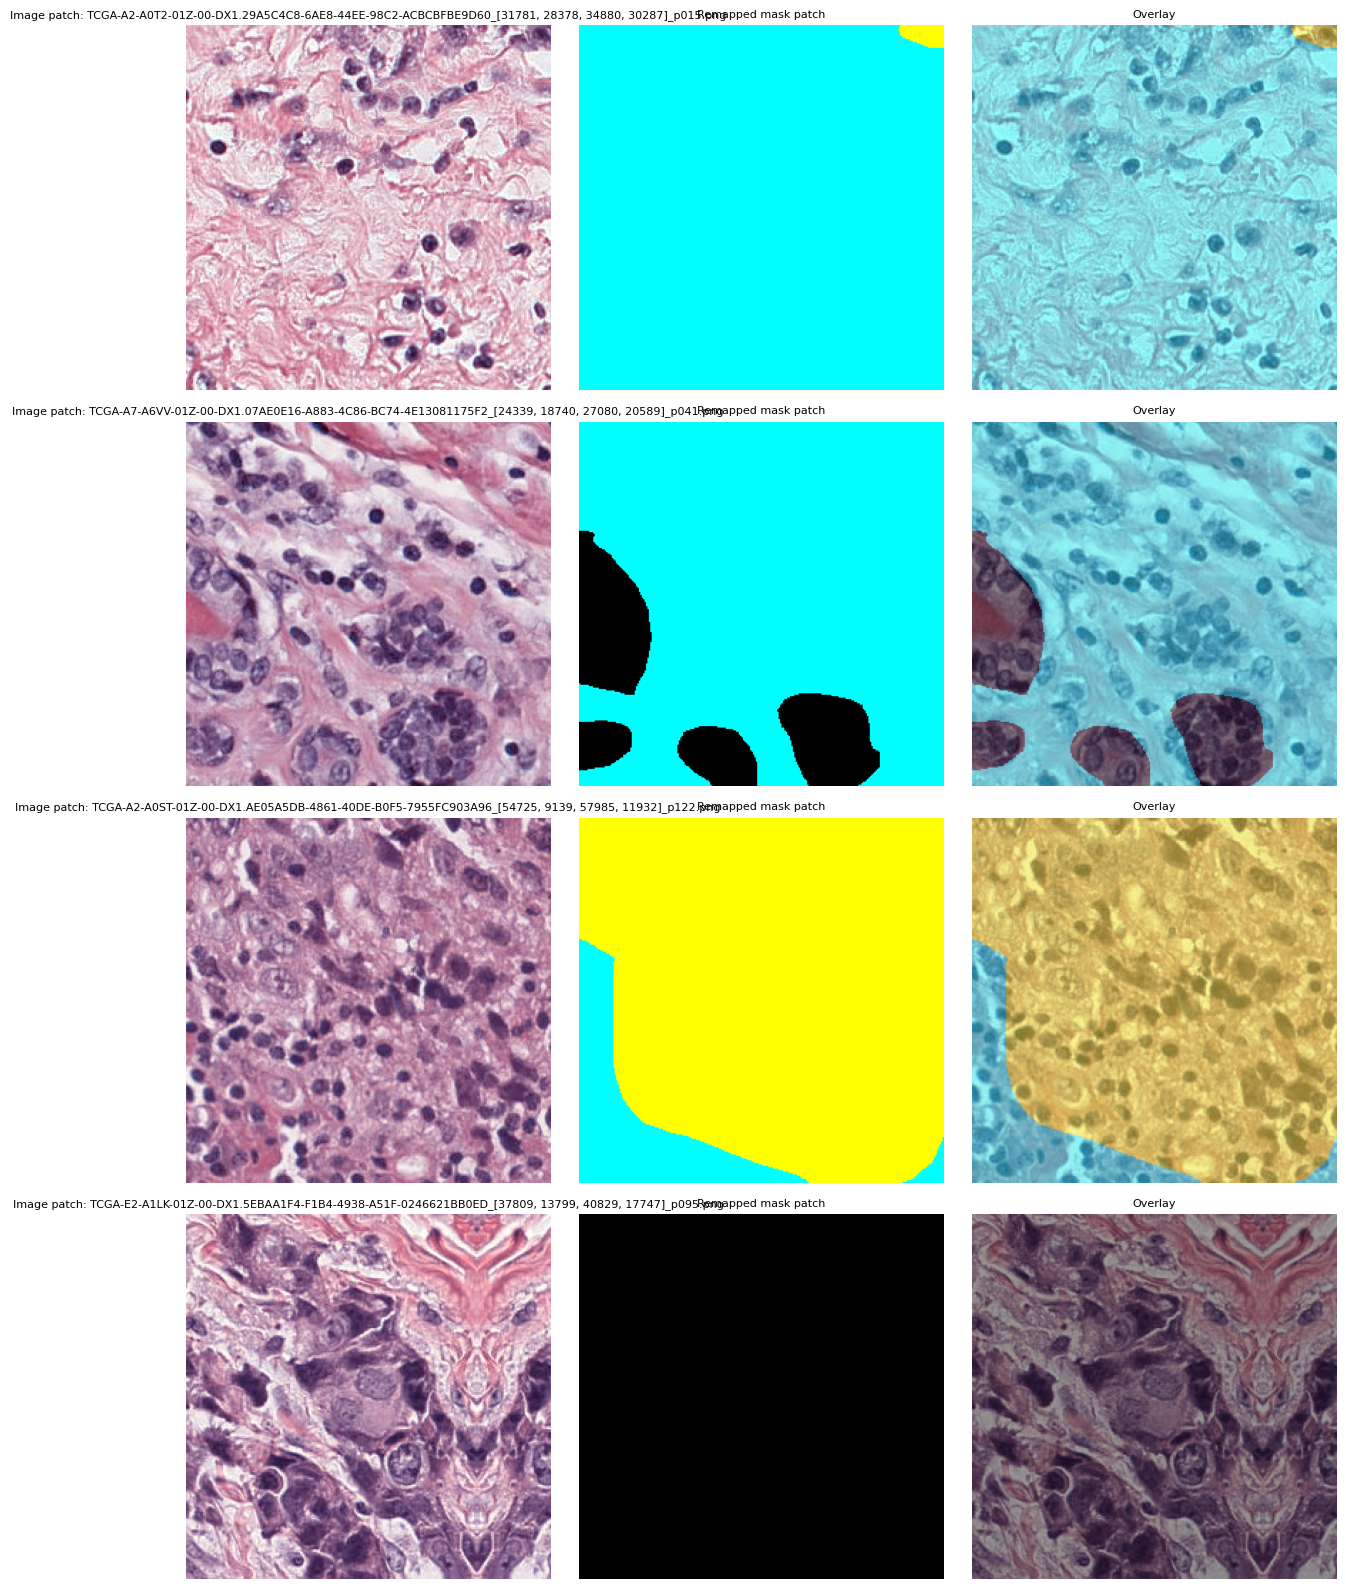

In [25]:
qc_files = os.listdir(os.path.join(OUTPUT_ROOT, 'images', 'train'))
qc_sample = random.sample(qc_files, min(4, len(qc_files)))

cmap = plt.matplotlib.colors.ListedColormap(['black', 'yellow', 'cyan'])  # Rest, Tumor, Stroma

fig, axes = plt.subplots(len(qc_sample), 3, figsize=(12, 4 * len(qc_sample)))
if len(qc_sample) == 1:
    axes = axes.reshape(1, -1)

for row, fname in enumerate(qc_sample):
    img = Image.open(os.path.join(OUTPUT_ROOT, 'images', 'train', fname))
    mask = np.asarray(Image.open(os.path.join(OUTPUT_ROOT, 'masks', 'train', fname)))

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Image patch: {fname}", fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask, cmap=cmap, vmin=0, vmax=2)
    axes[row, 1].set_title("Remapped mask patch", fontsize=8)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(img)
    axes[row, 2].imshow(mask, cmap=cmap, vmin=0, vmax=2, alpha=0.4)
    axes[row, 2].set_title("Overlay", fontsize=8)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()


## Step 11 — Reference: ImageNet normalization (applied at training time)

Saved patches are plain uint8 RGB PNGs (post stain-norm), **not** ImageNet-normalized. This
keeps them visually inspectable and reusable across different backbones. Apply this transform
in your UNet training DataLoader instead:


In [26]:
# Reference only — use this in your UNet training notebook's DataLoader, not here.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Example with torchvision:
# from torchvision import transforms
# transform = transforms.Compose([
#     transforms.ToTensor(),  # scales to [0, 1]
#     transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
# ])
print("ImageNet normalization constants (for reference in the training notebook):")
print(f"  mean = {IMAGENET_MEAN}")
print(f"  std  = {IMAGENET_STD}")


ImageNet normalization constants (for reference in the training notebook):
  mean = [0.485, 0.456, 0.406]
  std  = [0.229, 0.224, 0.225]


## Summary

- **Stain normalization:** Macenko, applied to every ROI before patching (required by baseline)
- **Class remap:** 7 original labels -> 3 (Rest/Tumor/Stroma), applied before patching
- **Patch size:** 256x256, non-overlapping, edge-padded
- **Split:** done at the image level (before patching) — 70/15/15, stratified by source
- **Saved format:** plain uint8 PNGs for both image and mask patches at `{OUTPUT_ROOT}`
- **ImageNet normalization:** documented as a training-time transform, not baked into saved files

**Next steps:**
1. Build the **UNet training notebook** — load these patches, apply ImageNet normalization in
   the DataLoader, train, validate (mIoU, per-class F1, confusion matrix)
2. Build the **YOLOv8 training notebook** for the Detection track (if not already done)


# TIGER Challenge — Segmentation Track: Model Training
## Configurable Architecture (UNet from scratch / UNet+pretrained encoder / DeepLabV3+)

**Track:** Tissue segmentation (Rest / Tumor / Stroma)
**Input:** The patch dataset produced by `04_DataPrep_Segmentation.ipynb`
(`images/{train,val,test}`, `masks/{train,val,test}`, 256x256 PNG patches)

### What this notebook does
1. **Explains every input you need to set** in one config cell
2. Loads the patch dataset and confirms counts
3. **Three swappable architectures**, selected by one config variable:
   - `unet_scratch` — a plain UNet implemented from scratch (no pretrained weights)
   - `unet_pretrained` — UNet with a pretrained ResNet encoder (via `segmentation-models-pytorch`)
   - `deeplabv3plus` — DeepLabV3+ with a pretrained encoder (via `segmentation-models-pytorch`)
4. **Albumentations** for joint image+mask augmentation (spatial transforms apply identically
   to both, which plain `torchvision.transforms` can't do out of the box)
5. **ImageNet normalization applied here** (this is the training-time step referenced in the
   data-prep notebook — patches were saved as plain uint8 so this is where it actually happens)
6. **Class-weighted loss** (optional) — using the class imbalance found in the Segmentation EDA
7. Validation metrics: **mIoU, per-class F1, confusion matrix**
8. A **model comparison table**, same pattern as the Detection training notebook

### Note on 'refining the model'
Per your last answer, no additional refinement stage (two-stage / ensembling) is included —
this notebook focuses purely on giving you the three swappable architectures cleanly.

> **Note:** Every custom component here (the from-scratch UNet, the Albumentations pipeline,
> the confusion-matrix-based mIoU/F1 computation) was unit-tested on synthetic data — including
> a forward+backward pass on all three architectures — before being placed in this notebook.
> The one thing not tested is against your actual Drive-saved patches, since I can't reach
> Google Drive from my sandbox.


In [27]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00


In [28]:
import os
import random
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if DEVICE.type == 'cpu':
    print("WARNING: No GPU detected. In Colab, go to Runtime > Change runtime type > GPU.")


Using device: cuda


## Step 1 — CONFIG: everything you need to set is here

| Setting | What it controls |
|---|---|
| `DATASET_ROOT` | Path to the output of `04_DataPrep_Segmentation.ipynb` (your Drive path) |
| `ARCHITECTURE` | `'unet_scratch'`, `'unet_pretrained'`, or `'deeplabv3plus'` |
| `ENCODER_NAME` | Only used for `unet_pretrained`/`deeplabv3plus`: e.g. `'resnet34'`, `'resnet50'`, `'efficientnet-b0'` |
| `EPOCHS`, `BATCH_SIZE` | Standard training hyperparameters (patches are already 256x256, matching the data prep) |
| `USE_AUGMENTATION` | Toggle the Albumentations pipeline on/off |
| `USE_CLASS_WEIGHTS` | If `True`, weight the loss inversely to class frequency (helps with the Rest-heavy imbalance found in the Segmentation EDA) |
| `LOSS_TYPE` | `'ce'` (cross-entropy) or `'dice_ce'` (Dice + cross-entropy combined — often better for segmentation with class imbalance) |


In [29]:
# ============================================================
# CONFIG — edit this cell
# ============================================================

# --- Paths ---
DATASET_ROOT = '/content/drive/MyDrive/tiger_dataset/segmentation_patches'  # from notebook 04
RUNS_ROOT = '/content/drive/MyDrive/tiger_dataset/segmentation_runs'         # where results/checkpoints go

# --- Architecture selection ---
ARCHITECTURE = 'unet_pretrained'   # 'unet_scratch' | 'unet_pretrained' | 'deeplabv3plus'
ENCODER_NAME = 'resnet34'          # only used for unet_pretrained / deeplabv3plus
ENCODER_WEIGHTS = 'imagenet'       # pretrained weights for the encoder; set to None to train from random init

# --- Classes ---
NUM_CLASSES = 3
CLASS_NAMES = ['Rest', 'Tumor', 'Stroma']  # matches the 7->3 remap from data prep

# --- Training hyperparameters ---
EPOCHS = 50
BATCH_SIZE = 16
PATCH_SIZE = 256                  # matches the patch size from data prep
LEARNING_RATE = 1e-4

# --- Loss ---
USE_CLASS_WEIGHTS = True          # inverse-frequency class weighting
LOSS_TYPE = 'dice_ce'             # 'ce' | 'dice_ce'

# --- Augmentation (Albumentations; joint image+mask spatial transforms) ---
USE_AUGMENTATION = True

# --- Normalization (applied here, at training time, as documented in the data-prep notebook) ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

os.makedirs(RUNS_ROOT, exist_ok=True)
print("Config set:")
print(f"  Architecture: {ARCHITECTURE}" +
      (f" (encoder={ENCODER_NAME}, weights={ENCODER_WEIGHTS})" if ARCHITECTURE != 'unet_scratch' else ""))
print(f"  Epochs: {EPOCHS}, Batch size: {BATCH_SIZE}, Patch size: {PATCH_SIZE}")
print(f"  Loss: {LOSS_TYPE}, class weights: {USE_CLASS_WEIGHTS}, augmentation: {USE_AUGMENTATION}")


Config set:
  Architecture: unet_pretrained (encoder=resnet34, weights=imagenet)
  Epochs: 50, Batch size: 16, Patch size: 256
  Loss: dice_ce, class weights: True, augmentation: True


In [30]:
def count_patches(split):
    img_dir = os.path.join(DATASET_ROOT, 'images', split)
    if not os.path.exists(img_dir):
        return 0
    return len([f for f in os.listdir(img_dir) if f.lower().endswith('.png')])

train_count = count_patches('train')
val_count = count_patches('val')
test_count = count_patches('test')
total_count = train_count + val_count + test_count

print(f"Train patches: {train_count}")
print(f"Val patches:   {val_count}")
print(f"Test patches:  {test_count}")
print(f"Total patches: {total_count}")

if total_count == 0:
    raise FileNotFoundError(
        f"No patches found under {DATASET_ROOT}. "
        f"Check that notebook 04_DataPrep_Segmentation.ipynb has been run and DATASET_ROOT is correct."
    )


Train patches: 15025
Val patches:   2214
Test patches:  3860
Total patches: 21099


In [31]:
if USE_CLASS_WEIGHTS:
    mask_dir = os.path.join(DATASET_ROOT, 'masks', 'train')
    mask_files = os.listdir(mask_dir)
    sample_files = random.sample(mask_files, min(300, len(mask_files)))

    class_pixel_counts = Counter()
    for fname in tqdm(sample_files, desc="Estimating class frequency"):
        arr = np.asarray(Image.open(os.path.join(mask_dir, fname)))
        vals, counts = np.unique(arr, return_counts=True)
        for v, c in zip(vals, counts):
            if v < NUM_CLASSES:
                class_pixel_counts[int(v)] += int(c)

    total_px = sum(class_pixel_counts.values())
    freqs = np.array([class_pixel_counts.get(i, 1) / total_px for i in range(NUM_CLASSES)])
    class_weights = 1.0 / (freqs + 1e-6)
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # normalize so avg weight = 1

    print("Estimated class frequencies:", dict(zip(CLASS_NAMES, freqs.round(4))))
    print("Computed class weights:", dict(zip(CLASS_NAMES, class_weights.round(3))))

    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
else:
    class_weights_tensor = None
    print("Class weighting disabled — using uniform weights.")


Estimating class frequency:   0%|          | 0/300 [00:00<?, ?it/s]

Estimated class frequencies: {'Rest': np.float64(0.4769), 'Tumor': np.float64(0.2334), 'Stroma': np.float64(0.2897)}
Computed class weights: {'Rest': np.float64(0.64), 'Tumor': np.float64(1.307), 'Stroma': np.float64(1.053)}


## Step 4 — Albumentations pipeline (joint image+mask augmentation)

Spatial transforms (flips, rotation, affine) apply **identically** to image and mask in the
same call — critical for segmentation, since augmenting them independently would misalign
pixels and labels. Color transforms only touch the image.


In [32]:
if USE_AUGMENTATION:
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),      # safe for histopathology — no canonical orientation
        A.RandomRotate90(p=0.5),
        A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])
else:
    train_transform = A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

# Validation/test never get augmented, only normalized
val_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print(f"Augmentation: {'ON' if USE_AUGMENTATION else 'OFF'}")


Augmentation: ON


In [33]:
class SegmentationPatchDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.filenames = sorted([f for f in os.listdir(images_dir) if f.lower().endswith('.png')])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img = np.asarray(Image.open(os.path.join(self.images_dir, fname)).convert('RGB'))
        mask = np.array(Image.open(os.path.join(self.masks_dir, fname)))

        if self.transform is not None:
            transformed = self.transform(image=img, mask=mask)
            img_t = transformed['image']
            mask_t = transformed['mask'].long()
        else:
            img_t = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            mask_t = torch.from_numpy(mask).long()

        return img_t, mask_t


train_ds = SegmentationPatchDataset(
    os.path.join(DATASET_ROOT, 'images', 'train'),
    os.path.join(DATASET_ROOT, 'masks', 'train'),
    transform=train_transform,
)
val_ds = SegmentationPatchDataset(
    os.path.join(DATASET_ROOT, 'images', 'val'),
    os.path.join(DATASET_ROOT, 'masks', 'val'),
    transform=val_transform,
)
test_ds = SegmentationPatchDataset(
    os.path.join(DATASET_ROOT, 'images', 'test'),
    os.path.join(DATASET_ROOT, 'masks', 'test'),
    transform=val_transform,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

# Quick shape sanity check
sample_img, sample_mask = train_ds[0]
print(f"Sample image tensor shape: {sample_img.shape}, mask shape: {sample_mask.shape}")


Train: 15025, Val: 2214, Test: 3860
Sample image tensor shape: torch.Size([3, 256, 256]), mask shape: torch.Size([256, 256])


## Step 6 — Model definition (three swappable architectures)

### `unet_scratch`
A plain encoder-decoder UNet with skip connections, implemented directly (no pretrained
weights, no external segmentation library) — this is the "from scratch" option.

### `unet_pretrained` / `deeplabv3plus`
Both use `segmentation-models-pytorch`, which provides well-tested implementations with a
choice of pretrained encoder backbones (ResNet, EfficientNet, etc.) — swapping `ENCODER_NAME`
in the config lets you try different backbones without touching this cell.


In [34]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNetFromScratch(nn.Module):
    """Plain UNet, no pretrained weights."""
    def __init__(self, in_channels=3, num_classes=3, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base_ch)
        self.enc2 = DoubleConv(base_ch, base_ch * 2)
        self.enc3 = DoubleConv(base_ch * 2, base_ch * 4)
        self.enc4 = DoubleConv(base_ch * 4, base_ch * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base_ch * 8, base_ch * 16)
        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, 2, stride=2)
        self.dec4 = DoubleConv(base_ch * 16, base_ch * 8)
        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 2, stride=2)
        self.dec3 = DoubleConv(base_ch * 8, base_ch * 4)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = DoubleConv(base_ch * 4, base_ch * 2)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = DoubleConv(base_ch * 2, base_ch)
        self.final = nn.Conv2d(base_ch, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)


def build_model(architecture):
    if architecture == 'unet_scratch':
        return UNetFromScratch(in_channels=3, num_classes=NUM_CLASSES)
    elif architecture == 'unet_pretrained':
        return smp.Unet(encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
                         in_channels=3, classes=NUM_CLASSES)
    elif architecture == 'deeplabv3plus':
        return smp.DeepLabV3Plus(encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
                                  in_channels=3, classes=NUM_CLASSES)
    else:
        raise ValueError(f"Unknown architecture: {architecture}")


model = build_model(ARCHITECTURE).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"✓ Built {ARCHITECTURE} — {n_params:,} parameters")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

✓ Built unet_pretrained — 24,436,659 parameters


## Step 7 — Loss function

`ce`: standard (optionally class-weighted) cross-entropy.
`dice_ce`: Dice loss + cross-entropy combined — Dice directly optimizes overlap (helps with
imbalanced classes like Tumor, which occupies far fewer pixels than Rest/Stroma).


In [35]:
def dice_loss(logits, targets, num_classes, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_onehot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    intersection = torch.sum(probs * targets_onehot, dims)
    cardinality = torch.sum(probs + targets_onehot, dims)
    dice_per_class = (2.0 * intersection + eps) / (cardinality + eps)
    return 1.0 - dice_per_class.mean()


ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

def compute_loss(logits, targets):
    if LOSS_TYPE == 'ce':
        return ce_loss_fn(logits, targets)
    elif LOSS_TYPE == 'dice_ce':
        return ce_loss_fn(logits, targets) + dice_loss(logits, targets, NUM_CLASSES)
    else:
        raise ValueError(f"Unknown LOSS_TYPE: {LOSS_TYPE}")

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


## Step 8 — Confusion-matrix-based metrics (mIoU, per-class F1)

We accumulate a running confusion matrix across a validation pass, then derive per-class IoU
and F1 from it directly — this is exact (no sampling approximation) and also gives us the
confusion matrix itself for free, useful for the evaluation notebook later.


In [36]:
def compute_confusion_matrix(preds_flat, targets_flat, num_classes):
    valid = (targets_flat >= 0) & (targets_flat < num_classes)
    cm = np.bincount(
        num_classes * targets_flat[valid].astype(int) + preds_flat[valid].astype(int),
        minlength=num_classes ** 2
    ).reshape(num_classes, num_classes)
    return cm


def metrics_from_confusion_matrix(cm, class_names):
    ious, f1s = {}, {}
    for i, name in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        ious[name] = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else float('nan')
        f1s[name] = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else float('nan')
    return ious, f1s


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    cm_total = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    total_loss = 0.0

    for images, masks in tqdm(loader, desc="Evaluating"):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images)
        loss = compute_loss(logits, masks)
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1).cpu().numpy().ravel()
        targets = masks.cpu().numpy().ravel()
        cm_total += compute_confusion_matrix(preds, targets, NUM_CLASSES)

    ious, f1s = metrics_from_confusion_matrix(cm_total, CLASS_NAMES)
    miou = np.nanmean(list(ious.values()))
    mean_f1 = np.nanmean(list(f1s.values()))
    avg_loss = total_loss / len(loader)

    return {
        'loss': avg_loss, 'miou': miou, 'mean_f1': mean_f1,
        'per_class_iou': ious, 'per_class_f1': f1s, 'confusion_matrix': cm_total,
    }


## Step 9 — Training loop

In [37]:
checkpoint_dir = os.path.join(RUNS_ROOT, f'{ARCHITECTURE}_run')
os.makedirs(checkpoint_dir, exist_ok=True)

history = {'train_loss': [], 'val_loss': [], 'val_miou': []}
best_miou = -1.0

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        logits = model(images)
        loss = compute_loss(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_train_loss = epoch_loss / len(train_loader)

    val_results = evaluate(model, val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_results['loss'])
    history['val_miou'].append(val_results['miou'])

    print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}  "
          f"val_loss={val_results['loss']:.4f}  val_mIoU={val_results['miou']:.4f}")

    torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'last.pt'))
    if val_results['miou'] > best_miou:
        best_miou = val_results['miou']
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best.pt'))
        print(f"  -> New best mIoU, checkpoint saved.")

print(f"\n✓ Training complete. Best val mIoU: {best_miou:.4f}")


Epoch 1/50:   0%|          | 0/940 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 1: train_loss=1.2220  val_loss=1.4419  val_mIoU=0.4241
  -> New best mIoU, checkpoint saved.


Epoch 2/50:   0%|          | 0/940 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/139 [00:00<?, ?it/s]

...

Epoch 15/50:   0%|          | 0/940 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 15: train_loss=0.7558  val_loss=1.4420  val_mIoU=0.4699


Epoch 16/50:   0%|          | 0/940 [00:00<?, ?it/s]

KeyboardInterrupt: 

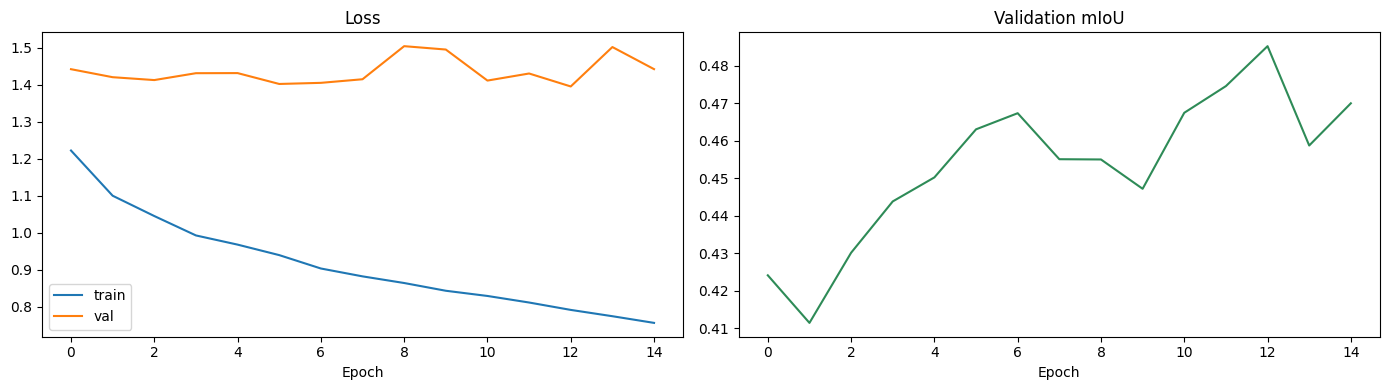

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_miou'], color='seagreen')
axes[1].set_title('Validation mIoU')
axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()


## Step 10 — Final evaluation on the test set + confusion matrix visualization

In [39]:
model.load_state_dict(torch.load(os.path.join(checkpoint_dir, 'best.pt')))
test_results = evaluate(model, test_loader)

print(f"Test loss: {test_results['loss']:.4f}")
print(f"Test mIoU: {test_results['miou']:.4f}")
print(f"Test mean F1: {test_results['mean_f1']:.4f}")
print("\nPer-class IoU:")
for name, iou in test_results['per_class_iou'].items():
    print(f"  {name}: {iou:.4f}")
print("\nPer-class F1:")
for name, f1 in test_results['per_class_f1'].items():
    print(f"  {name}: {f1:.4f}")


Evaluating:   0%|          | 0/242 [00:00<?, ?it/s]

Test loss: 1.1830
Test mIoU: 0.5655
Test mean F1: 0.7214

Per-class IoU:
  Rest: 0.5358
  Tumor: 0.5327
  Stroma: 0.6280

Per-class F1:
  Rest: 0.6977
  Tumor: 0.6951
  Stroma: 0.7715


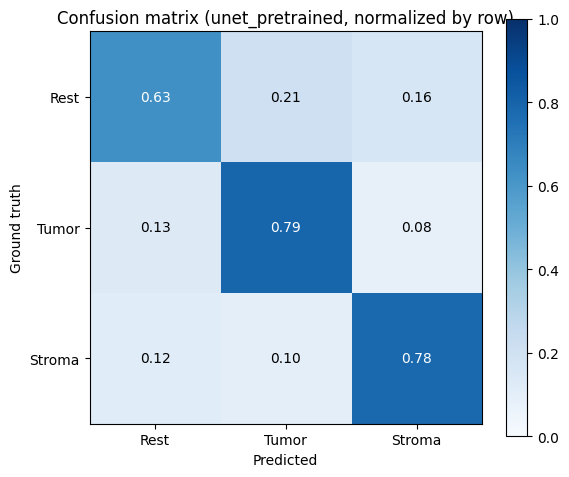

In [40]:
cm = test_results['confusion_matrix']
cm_normalized = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('Ground truth')
ax.set_title(f'Confusion matrix ({ARCHITECTURE}, normalized by row)')

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm_normalized[i,j]:.2f}", ha='center', va='center',
                color='white' if cm_normalized[i,j] > 0.5 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Step 11 — Visual QC: overlay predictions on sample test patches

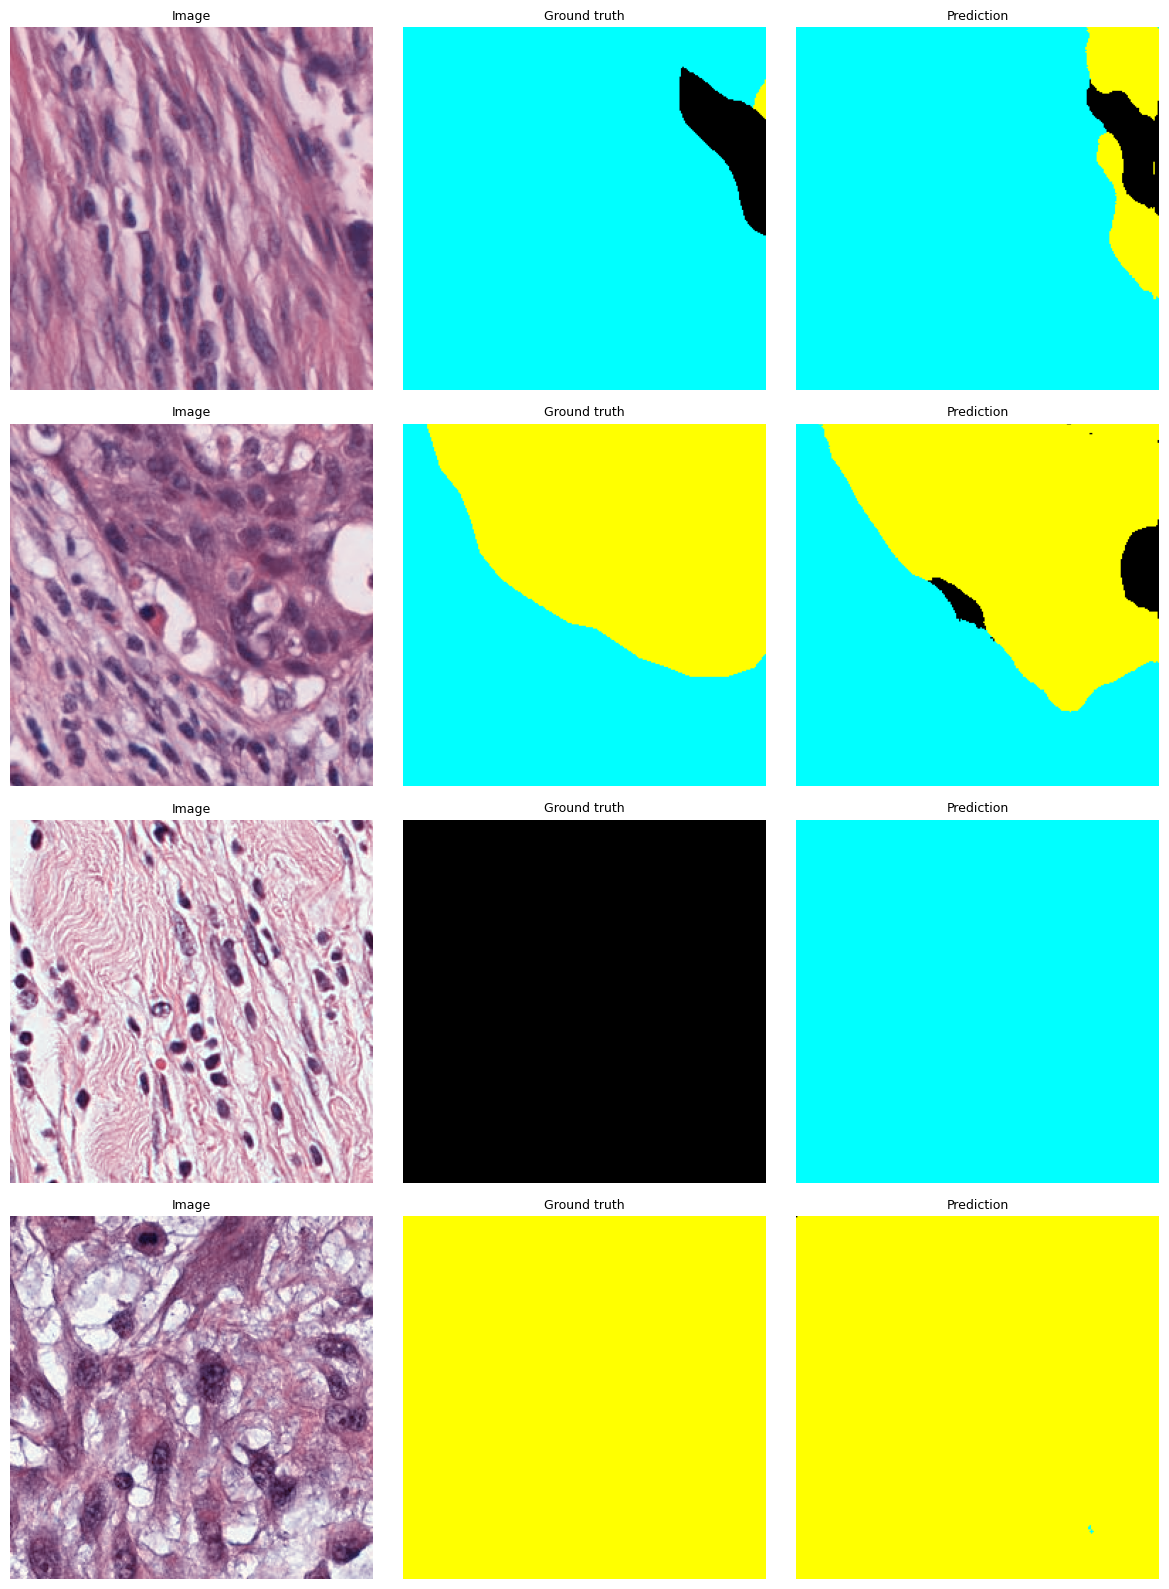

In [41]:
cmap = plt.matplotlib.colors.ListedColormap(['black', 'yellow', 'cyan'])

model.eval()
sample_indices = random.sample(range(len(test_ds)), min(4, len(test_ds)))

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(sample_indices):
    img_t, mask_t = test_ds[idx]
    with torch.no_grad():
        logits = model(img_t.unsqueeze(0).to(DEVICE))
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    # Un-normalize for display
    img_display = img_t.numpy().transpose(1, 2, 0)
    img_display = img_display * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_display = np.clip(img_display, 0, 1)

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title("Image", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_t.numpy(), cmap=cmap, vmin=0, vmax=2)
    axes[row, 1].set_title("Ground truth", fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred, cmap=cmap, vmin=0, vmax=2)
    axes[row, 2].set_title("Prediction", fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()


## Step 12 — Log this run to a comparison table

Same pattern as the Detection training notebook — run this multiple times with different
`ARCHITECTURE`/`ENCODER_NAME` settings, and results accumulate here for comparison.


In [42]:
comparison_csv_path = os.path.join(RUNS_ROOT, 'model_comparison.csv')

run_row = {
    'architecture': ARCHITECTURE,
    'encoder': ENCODER_NAME if ARCHITECTURE != 'unet_scratch' else 'n/a',
    'loss_type': LOSS_TYPE,
    'class_weights': USE_CLASS_WEIGHTS,
    'augmentation': USE_AUGMENTATION,
    'test_miou': test_results['miou'],
    'test_mean_f1': test_results['mean_f1'],
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
}
for name in CLASS_NAMES:
    run_row[f'iou_{name}'] = test_results['per_class_iou'][name]
    run_row[f'f1_{name}'] = test_results['per_class_f1'][name]

if os.path.exists(comparison_csv_path):
    comparison_df = pd.read_csv(comparison_csv_path)
    comparison_df = pd.concat([comparison_df, pd.DataFrame([run_row])], ignore_index=True)
else:
    comparison_df = pd.DataFrame([run_row])

comparison_df.to_csv(comparison_csv_path, index=False)
print(f"Logged to {comparison_csv_path}\n")
print(comparison_df[['architecture', 'encoder', 'test_miou', 'test_mean_f1']])


Logged to /content/drive/MyDrive/tiger_dataset/segmentation_runs/model_comparison.csv

      architecture   encoder  test_miou  test_mean_f1
0  unet_pretrained  resnet34    0.56549      0.721445


In [43]:
if len(comparison_df) > 1:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(comparison_df))
    labels = [f"{row['architecture']}\n({row['encoder']})" for _, row in comparison_df.iterrows()]

    width = 0.35
    ax.bar([i - width/2 for i in x], comparison_df['test_miou'], width, label='mIoU')
    ax.bar([i + width/2 for i in x], comparison_df['test_mean_f1'], width, label='mean F1')

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Score')
    ax.set_title('Segmentation model comparison')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Run this notebook with different ARCHITECTURE settings to build up the comparison chart.")


Run this notebook with different ARCHITECTURE settings to build up the comparison chart.


# TIGER Challenge — Segmentation Track: Evaluation Report
## Comparison Tables, Metric Charts, and a Standalone Markdown Report

**Input:** `model_comparison.csv` produced by `06_Training_Segmentation.ipynb` (one row per
training run you logged — different architectures/encoders/loss settings)
**Output:** Rendered tables/charts in this notebook, plus a standalone `SEGMENTATION_REPORT.md`
file suitable for your GitHub README or final submission.

### What this notebook does
1. Loads all logged runs from `model_comparison.csv`
2. Renders a clean comparison table, sorted by mIoU
3. Generates comparison charts (mIoU / mean F1 across runs, plus per-class IoU breakdown)
4. Assembles everything into a **Markdown report file** you can drop straight into your repo


In [44]:
!pip install -q tabulate

In [45]:
import os
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.precision', 4)


## Step 1 — CONFIG

| Setting | What it controls |
|---|---|
| `RUNS_ROOT` | Same path as `RUNS_ROOT` in `06_Training_Segmentation.ipynb` — where `model_comparison.csv` lives |
| `REPORT_OUTPUT_PATH` | Where the final `.md` report file is written |
| `PROJECT_TITLE` / `DATASET_SUMMARY` | Free-text fields dropped into the report header — edit to match your actual run |


In [46]:
RUNS_ROOT = '/content/drive/MyDrive/tiger_dataset/segmentation_runs'
REPORT_OUTPUT_PATH = os.path.join(RUNS_ROOT, 'SEGMENTATION_REPORT.md')
CHART_OUTPUT_PATH = os.path.join(RUNS_ROOT, 'segmentation_comparison_chart.png')
PER_CLASS_CHART_PATH = os.path.join(RUNS_ROOT, 'segmentation_per_class_iou_chart.png')

PROJECT_TITLE = "TIGER Grand Challenge — Segmentation Track (Tumor / Stroma / Rest)"

CLASS_NAMES = ['Rest', 'Tumor', 'Stroma']

# Edit these to match your actual dataset run (from the EDA / data-prep notebooks)
DATASET_SUMMARY = {
    'Patch size': '256x256',
    'Sources': 'RUMC, JB, TCGA',
    'Preprocessing': 'Macenko stain normalization, 7-class -> 3-class remap (Rest/Tumor/Stroma), ImageNet normalization at training time',
    'Split': '70/15/15 at the image (slide) level before patching, stratified by source',
}

print(f"Reading comparison results from: {RUNS_ROOT}")
print(f"Report will be written to: {REPORT_OUTPUT_PATH}")


Reading comparison results from: /content/drive/MyDrive/tiger_dataset/segmentation_runs
Report will be written to: /content/drive/MyDrive/tiger_dataset/segmentation_runs/SEGMENTATION_REPORT.md


In [47]:
comparison_csv_path = os.path.join(RUNS_ROOT, 'model_comparison.csv')

if not os.path.exists(comparison_csv_path):
    raise FileNotFoundError(
        f"No model_comparison.csv found at {comparison_csv_path}. "
        f"Run 06_Training_Segmentation.ipynb at least once first (each run appends a row here)."
    )

comparison_df = pd.read_csv(comparison_csv_path)
print(f"Loaded {len(comparison_df)} logged run(s).")
comparison_df


Loaded 1 logged run(s).


,architecture,encoder,loss_type,class_weights,augmentation,test_miou,test_mean_f1,epochs,batch_size,iou_Rest,f1_Rest,iou_Tumor,f1_Tumor,iou_Stroma,f1_Stroma
0,unet_pretrained,resnet34,dice_ce,True,True,0.5655,0.7214,50,16,0.5358,0.6977,0.5327,0.6951,0.628,0.7715


In [48]:
base_cols = ['architecture', 'encoder', 'loss_type', 'class_weights', 'augmentation',
             'test_miou', 'test_mean_f1']
base_cols = [c for c in base_cols if c in comparison_df.columns]
per_class_cols = [c for c in comparison_df.columns if c.startswith('iou_') or c.startswith('f1_')]

sorted_df = comparison_df[base_cols + per_class_cols].sort_values(
    'test_miou', ascending=False
).reset_index(drop=True)

sorted_df


,architecture,encoder,loss_type,class_weights,augmentation,test_miou,test_mean_f1,iou_Rest,f1_Rest,iou_Tumor,f1_Tumor,iou_Stroma,f1_Stroma
0,unet_pretrained,resnet34,dice_ce,True,True,0.5655,0.7214,0.5358,0.6977,0.5327,0.6951,0.628,0.7715


In [49]:
best_run = sorted_df.iloc[0]
print("Best run:")
print(best_run)


Best run:
architecture     unet_pretrained
encoder                 resnet34
loss_type                dice_ce
class_weights               True
augmentation                True
test_miou                 0.5655
test_mean_f1              0.7214
iou_Rest                  0.5358
f1_Rest                   0.6977
iou_Tumor                 0.5327
f1_Tumor                  0.6951
iou_Stroma                 0.628
f1_Stroma                 0.7715
Name: 0, dtype: object


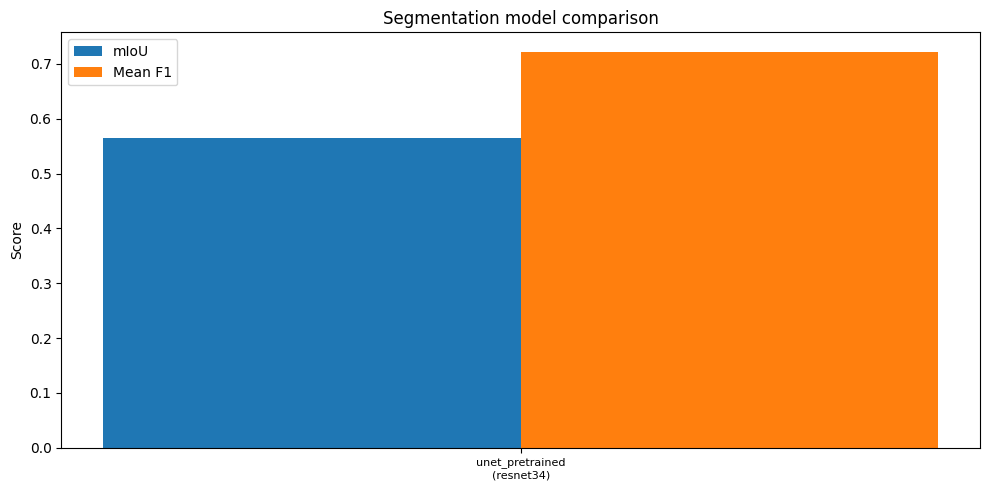


Chart saved to: /content/drive/MyDrive/tiger_dataset/segmentation_runs/segmentation_comparison_chart.png


In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(sorted_df))
labels = [f"{row['architecture']}\n({row['encoder']})" for _, row in sorted_df.iterrows()]

width = 0.35
ax.bar([i - width/2 for i in x], sorted_df['test_miou'], width, label='mIoU')
ax.bar([i + width/2 for i in x], sorted_df['test_mean_f1'], width, label='Mean F1')

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Segmentation model comparison')
ax.legend()
plt.tight_layout()
plt.savefig(CHART_OUTPUT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved to: {CHART_OUTPUT_PATH}")


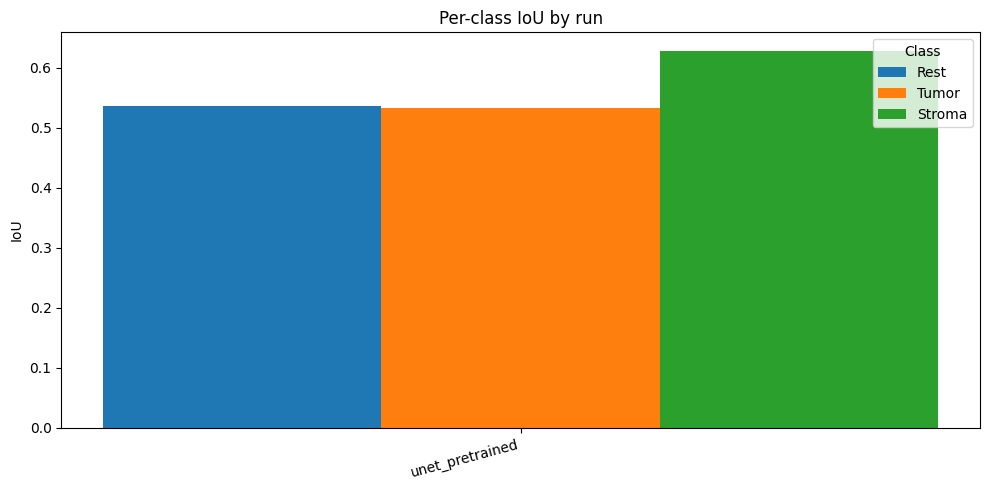

Per-class chart saved to: /content/drive/MyDrive/tiger_dataset/segmentation_runs/segmentation_per_class_iou_chart.png


In [51]:
iou_cols = [f'iou_{name}' for name in CLASS_NAMES if f'iou_{name}' in sorted_df.columns]

if iou_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(sorted_df))
    width = 0.8 / len(iou_cols)

    for i, col in enumerate(iou_cols):
        class_name = col.replace('iou_', '')
        offset = (i - (len(iou_cols) - 1) / 2) * width
        ax.bar([xi + offset for xi in x], sorted_df[col], width, label=class_name)

    ax.set_xticks(list(x))
    ax.set_xticklabels([row['architecture'] for _, row in sorted_df.iterrows()], rotation=15, ha='right')
    ax.set_ylabel('IoU')
    ax.set_title('Per-class IoU by run')
    ax.legend(title='Class')
    plt.tight_layout()
    plt.savefig(PER_CLASS_CHART_PATH, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Per-class chart saved to: {PER_CLASS_CHART_PATH}")
else:
    print("No per-class IoU columns found in the comparison CSV — skipping this chart.")


In [52]:
def build_markdown_report():
    lines = []
    lines.append(f"# {PROJECT_TITLE}")
    lines.append("")
    lines.append(f"*Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}*")
    lines.append("")
    lines.append("## Dataset Summary")
    lines.append("")
    for k, v in DATASET_SUMMARY.items():
        lines.append(f"- **{k}:** {v}")
    lines.append("")
    lines.append("## Results")
    lines.append("")
    lines.append(f"{len(sorted_df)} model configuration(s) evaluated. Sorted by mIoU "
                  f"(mean Intersection-over-Union across {', '.join(CLASS_NAMES)}).")
    lines.append("")
    lines.append(sorted_df.to_markdown(index=False))
    lines.append("")
    best_line = (f"**Best configuration:** `{best_run['architecture']}`"
                 + (f" (encoder: {best_run['encoder']})" if best_run.get('encoder', 'n/a') != 'n/a' else "")
                 + f" — mIoU = {best_run['test_miou']:.4f}, mean F1 = {best_run['test_mean_f1']:.4f}")
    lines.append(best_line)
    lines.append("")
    lines.append("## Comparison Charts")
    lines.append("")
    lines.append(f"![Segmentation model comparison]({os.path.basename(CHART_OUTPUT_PATH)})")
    lines.append("")
    lines.append(f"![Per-class IoU comparison]({os.path.basename(PER_CLASS_CHART_PATH)})")
    lines.append("")
    lines.append("## Notes")
    lines.append("")
    lines.append("- Stain normalization (Macenko) and the 7-class -> 3-class remap "
                  "(`{0:0, 1:1, 2:2, 3:0, 4:0, 5:0, 6:2, 7:0}`) follow the official TIGER "
                  "baseline directly — these were not open decisions for this track.")
    lines.append("- `class_weights=True` runs use inverse-frequency loss weighting to address "
                  "the Rest-heavy class imbalance found in the Segmentation EDA.")
    return "\n".join(lines)


report_markdown = build_markdown_report()

with open(REPORT_OUTPUT_PATH, 'w') as f:
    f.write(report_markdown)

print(f"Report written to: {REPORT_OUTPUT_PATH}\n")
print("--- Preview ---\n")
print(report_markdown)


Report written to: /content/drive/MyDrive/tiger_dataset/segmentation_runs/SEGMENTATION_REPORT.md

--- Preview ---

# TIGER Grand Challenge — Segmentation Track (Tumor / Stroma / Rest)

*Report generated: 2026-07-22 10:12*

## Dataset Summary

- **Patch size:** 256x256
- **Sources:** RUMC, JB, TCGA
- **Preprocessing:** Macenko stain normalization, 7-class -> 3-class remap (Rest/Tumor/Stroma), ImageNet normalization at training time
- **Split:** 70/15/15 at the image (slide) level before patching, stratified by source

## Results

1 model configuration(s) evaluated. Sorted by mIoU (mean Intersection-over-Union across Rest, Tumor, Stroma).

| architecture    | encoder   | loss_type   | class_weights   | augmentation   |   test_miou |   test_mean_f1 |   iou_Rest |   f1_Rest |   iou_Tumor |   f1_Tumor |   iou_Stroma |   f1_Stroma |
|:----------------|:----------|:------------|:----------------|:---------------|------------:|---------------:|-----------:|----------:|------------:|-----------